In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
import importlib
from src import target as tgt
importlib.reload(tgt)

<module 'src.target' from '/content/drive/MyDrive/Early-Sepsis-Detection/src/target.py'>

# 07 — Feature Engineering
### Early Sepsis Detection — Phase 8

Builds the final patient-level modeling dataset for the **primary
prediction window** (see `config.PRIMARY_PREDICTION_WINDOW_HOURS`), using
the leakage-safe window logic verified in `06_target_construction.ipynb`.

**Important:** aggregates are computed from RAW (pre-LOCF) hourly data,
per the design decision documented in `src/feature_engineering.py` —
this preserves the true measurement-frequency signal found to be
predictive in Phase 5 (e.g. Lactate ordered ~2.3x more often in septic
patients).


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import target as tgt
from src import feature_engineering as fe

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)


## 1. Load raw (pre-LOCF) long-format data and rebuild the leakage-safe window table

In [4]:
raw_df = pd.read_parquet(config.INTERIM_LONG_PARQUET)
print("Raw shape:", raw_df.shape)

PRIMARY_WINDOW = config.PRIMARY_PREDICTION_WINDOW_HOURS
window_table = tgt.build_patient_level_window_labels(raw_df, PRIMARY_WINDOW)
print(f"Primary window: {PRIMARY_WINDOW}h | "
      f"{window_table['included'].sum()} / {len(window_table)} patients usable")


Raw shape: (1552210, 43)


2026-09-14 06:02:17,579 | WARNING | src.target | Window=6h: excluding 965/40336 total patients (370 due to onset_hour<=1, 595 due to no data within the usable window despite a later onset).


Primary window: 6h | 39371 / 40336 patients usable


## 2. Slice to the leakage-safe window (re-verified, matches Phase 7's Section 5 result)

In [5]:
sliced = tgt.slice_features_to_window(raw_df, window_table)
print("Sliced shape:", sliced.shape)
print("Unique patients in sliced data:", sliced[config.PATIENT_ID_COL].nunique())


Sliced shape: (219373, 43)
Unique patients in sliced data: 39371


## 3. Build patient-level features

This computes ~10 features per clinical variable (34 variables) + 4 derived
features + demographics — expect several hundred output columns.


In [6]:
patient_df = fe.build_patient_level_features(sliced, window_table)
print("Patient-level dataset shape:", patient_df.shape)
patient_df.head()


2026-09-14 06:06:26,948 | INFO | src.feature_engineering | Computed temporal features for 39371 patients x 38 source columns (458 output columns).
INFO:src.feature_engineering:Computed temporal features for 39371 patients x 38 source columns (458 output columns).
2026-09-14 06:06:27,814 | INFO | src.feature_engineering | Final patient-level feature table: 39371 patients x 467 columns.
INFO:src.feature_engineering:Final patient-level feature table: 39371 patients x 467 columns.


Patient-level dataset shape: (39371, 467)


,patient_id,HR_mean,HR_median,HR_min,HR_max,HR_std,HR_first,HR_last,HR_change,HR_abs_change,HR_count,HR_missing_ratio,HR_slope,O2Sat_mean,O2Sat_median,O2Sat_min,O2Sat_max,O2Sat_std,O2Sat_first,O2Sat_last,O2Sat_change,O2Sat_abs_change,O2Sat_count,O2Sat_missing_ratio,O2Sat_slope,Temp_mean,Temp_median,Temp_min,Temp_max,Temp_std,Temp_first,Temp_last,Temp_change,Temp_abs_change,Temp_count,Temp_missing_ratio,Temp_slope,SBP_mean,SBP_median,SBP_min,...,PulsePressure_last,PulsePressure_change,PulsePressure_abs_change,PulsePressure_count,PulsePressure_missing_ratio,PulsePressure_slope,SaO2_FiO2_ratio_mean,SaO2_FiO2_ratio_median,SaO2_FiO2_ratio_min,SaO2_FiO2_ratio_max,SaO2_FiO2_ratio_std,SaO2_FiO2_ratio_first,SaO2_FiO2_ratio_last,SaO2_FiO2_ratio_change,SaO2_FiO2_ratio_abs_change,SaO2_FiO2_ratio_count,SaO2_FiO2_ratio_missing_ratio,SaO2_FiO2_ratio_slope,TempAbnormal_mean,TempAbnormal_median,TempAbnormal_min,TempAbnormal_max,TempAbnormal_std,TempAbnormal_first,TempAbnormal_last,TempAbnormal_change,TempAbnormal_abs_change,TempAbnormal_count,TempAbnormal_missing_ratio,TempAbnormal_slope,n_hours_used,Age,Gender,Unit1,Unit2,HospAdmTime,source_set,label,onset_hour,usable_hours
0,p000001,97.8,97.0,89.0,110.0,8.871302,97.0,110.0,13.0,13.0,5,0.166667,4.0,93.7,95.0,88.5,99.0,4.055860,95.0,91.0,-4.0,4.0,5,0.166667,-1.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.000000,NaN,114.0,122.0,98.0,...,NaN,NaN,NaN,0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.000000,NaN,6,83.139999,0.0,NaN,NaN,-0.030000,A,0,NaN,6.0
1,p000002,68.2,64.0,56.0,94.0,14.906374,61.0,94.0,33.0,33.0,5,0.166667,6.8,99.2,99.0,98.0,100.0,0.836660,99.0,100.0,1.0,1.0,5,0.166667,0.30,36.330000,36.330000,36.220001,36.439999,0.155562,36.439999,36.220001,-0.219997,0.219997,2,0.666667,-0.054999,137.2,124.0,120.0,...,128.0,47.0,47.0,5,0.166667,8.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0.666667,0.0,6,75.910004,0.0,0.0,1.0,-98.599998,A,0,NaN,6.0
2,p000003,88.6,89.0,84.0,93.0,3.361547,87.0,84.0,-3.0,3.0,5,0.166667,-1.0,96.4,97.0,95.0,97.0,0.894427,96.0,97.0,1.0,1.0,5,0.166667,0.20,37.110001,37.110001,37.110001,37.110001,NaN,37.110001,37.110001,0.000000,0.000000,1,0.833333,NaN,134.0,131.0,128.0,...,92.0,5.0,5.0,2,0.666667,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1,0.833333,NaN,6,45.820000,0.0,1.0,0.0,-1195.709961,A,0,NaN,6.0
3,p000004,107.8,107.5,103.5,113.0,3.402205,103.5,107.0,3.5,3.5,5,0.166667,1.2,98.4,98.5,96.5,100.0,1.635543,97.0,100.0,3.0,3.0,5,0.166667,0.75,36.779999,36.779999,36.779999,36.779999,NaN,36.779999,36.779999,0.000000,0.000000,1,0.833333,NaN,118.1,117.5,107.5,...,64.0,8.5,8.5,5,0.166667,1.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1,0.833333,NaN,6,65.709999,0.0,0.0,1.0,-8.770000,A,0,NaN,6.0
4,p000005,76.4,74.0,71.0,84.0,5.412947,84.0,71.0,-13.0,13.0,5,0.000000,-3.3,97.7,97.5,97.0,99.0,0.836660,97.5,97.0,-0.5,0.5,5,0.000000,-0.20,37.250000,37.250000,37.220001,37.279999,0.042425,37.279999,37.220001,-0.059998,0.059998,2,0.600000,-0.029999,144.1,144.0,140.5,...,NaN,NaN,NaN,0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0.600000,0.0,5,28.090000,1.0,1.0,0.0,-0.050000,A,0,NaN,6.0


In [7]:
# Diagnostic: find patients whose earliest recorded ICULOS is already > 6
# (which would explain why they silently vanish from the 6h-window feature table)

min_iculos = raw_df.groupby("patient_id")["ICULOS"].min()
print("Distribution of each patient's FIRST recorded ICULOS value:")
print(min_iculos.describe())
print()
print("Patients whose first ICULOS > 6:", (min_iculos > 6).sum())
print("Patients whose first ICULOS > 1:", (min_iculos > 1).sum())

# Cross-check against the window table's "included" patients specifically
included_pids = window_table[window_table["included"]]["patient_id"]
included_min_iculos = min_iculos.reindex(included_pids)
n_would_vanish = (included_min_iculos > config.PRIMARY_PREDICTION_WINDOW_HOURS).sum()
print()
print(f"Of the {len(included_pids)} patients marked 'included', "
      f"{n_would_vanish} have first ICULOS > {config.PRIMARY_PREDICTION_WINDOW_HOURS} "
      f"and would produce ZERO rows when sliced to the {config.PRIMARY_PREDICTION_WINDOW_HOURS}h window.")

# For positive patients specifically, also check against their OWN usable_hours
pos_check = window_table[(window_table["included"]) & (window_table["label"] == 1)].copy()
pos_check["first_iculos"] = pos_check["patient_id"].map(min_iculos)
n_pos_vanish = (pos_check["first_iculos"] > pos_check["usable_hours"]).sum()
print(f"Of {len(pos_check)} included POSITIVE patients, {n_pos_vanish} have "
      f"first ICULOS > their own usable_hours cutoff.")

Distribution of each patient's FIRST recorded ICULOS value:
count    40336.000000
mean         1.528114
std          2.806628
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        304.000000
Name: ICULOS, dtype: float64

Patients whose first ICULOS > 6: 542
Patients whose first ICULOS > 1: 8793

Of the 39371 patients marked 'included', 0 have first ICULOS > 6 and would produce ZERO rows when sliced to the 6h window.
Of 2463 included POSITIVE patients, 0 have first ICULOS > their own usable_hours cutoff.


## 4. Sanity checks on the engineered dataset

In [8]:
print("Label distribution:")
display(patient_df["label"].value_counts(normalize=True) * 100)

print()
print("n_hours_used distribution:")
display(patient_df["n_hours_used"].describe())

# Confirm every row has a valid patient_id and no fully-duplicated patients
print()
print("Duplicate patient_id rows:", patient_df[config.PATIENT_ID_COL].duplicated().sum())


Label distribution:


,proportion
label,
0,93.744126
1,6.255874



n_hours_used distribution:


,n_hours_used
count,39371.000000
mean,5.571944
std,0.995838
min,1.000000
25%,6.000000
50%,6.000000
75%,6.000000
max,6.000000



Duplicate patient_id rows: 0


## 5. Missingness in engineered features

**What?** Even after feature engineering, some `_mean`/`_std`/etc. columns
will be NaN for patients who never had that variable measured at all in
their window (e.g. a lab never ordered in the first 6 hours). This is
EXPECTED and will be handled by the training-set-only imputer in
Phase 11 — never here.


,missing_pct
Bilirubin_direct_std,99.933962
Bilirubin_direct_slope,99.933962
Bilirubin_total_std,99.710447
Bilirubin_total_slope,99.710447
Fibrinogen_slope,99.314216
Fibrinogen_std,99.314216
Alkalinephos_std,99.022123
Alkalinephos_slope,99.022123
AST_std,99.014503
AST_slope,99.014503


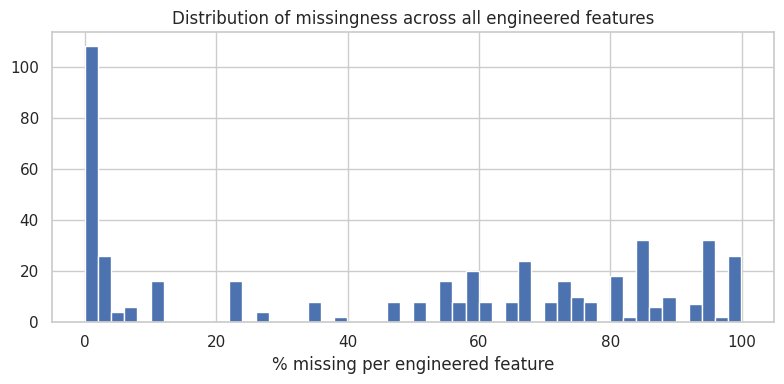

In [9]:
feature_missingness = (patient_df.isna().mean() * 100).sort_values(ascending=False)
display(feature_missingness.head(30).to_frame("missing_pct"))

plt.figure(figsize=(8, 4))
feature_missingness.hist(bins=50)
plt.xlabel("% missing per engineered feature")
plt.title("Distribution of missingness across all engineered features")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "07_engineered_feature_missingness.png", dpi=150)
plt.show()


## 6. Quick univariate signal check (NOT a model — just a sanity check)

**What?** For a few known-relevant features, compare their mean value
between the two label groups. This is purely descriptive — checking that
the engineered features actually differ by label in the expected direction
BEFORE any model is trained, so an obvious bug (e.g. a feature that's
identical across both groups when it shouldn't be) is caught early.


In [10]:
check_features = ["Lactate_count", "Lactate_missing_ratio", "HR_mean", "Resp_mean",
                   "MAP_mean", "WBC_mean", "ShockIndex_mean", "TempAbnormal_mean"]
check_features = [c for c in check_features if c in patient_df.columns]

summary = patient_df.groupby("label")[check_features].mean().T
summary.columns = ["Negative", "Positive"]
summary["difference"] = summary["Positive"] - summary["Negative"]
display(summary)


,Negative,Positive,difference
Lactate_count,0.253631,0.520097,0.266467
Lactate_missing_ratio,0.950200,0.893964,-0.056236
HR_mean,83.937433,88.009262,4.071829
Resp_mean,17.848191,19.195220,1.347029
MAP_mean,83.669918,80.709212,-2.960706
WBC_mean,11.758784,12.765494,1.006710
ShockIndex_mean,0.702964,0.754788,0.051824
TempAbnormal_mean,0.166152,0.218790,0.052639


## 7. Save the final patient-level dataset

In [11]:
patient_df.to_parquet(config.PROCESSED_PATIENT_LEVEL_PARQUET, index=False)
print(f"Saved to {config.PROCESSED_PATIENT_LEVEL_PARQUET}")
print("Final shape:", patient_df.shape)


Saved to /content/drive/MyDrive/Early-Sepsis-Detection/data/processed/patient_level_features.parquet
Final shape: (39371, 467)


---
### What to send back to Claude after running this notebook

- Section 3's shape (rows x columns) — should be ~2,562 patients (40,336 total
  minus the 370 excluded for onset_hour<=1... note: negative patients are
  never excluded, so expect roughly 37,404 negative + (2932-370)=2562 positive
  = ~39,966 total patients)
- Section 4's label distribution and `n_hours_used` describe() output
- Section 6's comparison table (does Lactate_count, ShockIndex_mean, etc.
  differ in the expected direction between Positive and Negative?)

With that, **Phase 8 is complete**, and we move to **Phase 10 (Patient-Level
Train/Val/Test Split)** — Phase 9 (comparing 6h/12h/24h windows) is noted as
a labeled secondary experiment to revisit after the primary pipeline
(Phases 10-23) is working end-to-end.
